# Imports

In [8]:
# =============================================================================
# Imports
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import logging
from pathlib import Path

# Make the kernel robust if launched through VSCode/Jupyter rather than
# from an already activated conda shell.
CONDA_PREFIX = Path(sys.executable).resolve().parents[1]
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["PYTHONNOUSERSITE"] = "1"

# Prefer the active conda environment libraries on Juno.
os.environ["LD_LIBRARY_PATH"] = (
    f"{CONDA_PREFIX / 'lib'}:" + os.environ.get("LD_LIBRARY_PATH", "")
)

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import squidpy as sq
import cellcharter as cc
import scvi
import torch
import matplotlib.pyplot as plt

from lightning.pytorch import seed_everything
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score,
)
from scipy.optimize import linear_sum_assignment

try:
    from IPython.display import display
except Exception:
    display = print

# Keep numerical behavior reasonably reproducible on Ampere GPUs.
torch.set_float32_matmul_precision("high")

print("Python:", sys.executable)
print("CONDA_PREFIX:", CONDA_PREFIX)
print("cellcharter:", getattr(cc, "__version__", cc.__file__))
print("scvi:", scvi.__version__)
print("scanpy:", sc.__version__)
print("squidpy:", sq.__version__)
print("torch:", torch.__version__, "cuda:", torch.version.cuda, "available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("numpy:", np.__version__)
print("pandas:", pd.__version__)


Python: /work/dal875013/conda_envs/cellcharter_env/bin/python
CONDA_PREFIX: /work/dal875013/conda_envs/cellcharter_env
cellcharter: 0.3.7
scvi: 1.4.2
scanpy: 1.11.5
squidpy: 1.8.1
torch: 2.5.1 cuda: 12.4 available: True
GPU: NVIDIA A30
numpy: 2.2.6
pandas: 2.2.3


# USER CONFIGURATION — edit these to match your environment

In [9]:
# =============================================================================
# USER CONFIGURATION
# =============================================================================

# Path to cloned CellCharter repo. This is not strictly required if the package
# was installed editable, but keeping it mirrors the attached DLPFC CellCharter format.
CELLCHARTER_ROOT = Path(r"/work/dal875013/projects/mocha/methods/cellcharter")

# Path to the folder containing CRC_CMS_10x .h5ad files.
# Expected files are usually SCE_<sample>.h5ad, but the loader below also
# searches for any *<sample>*.h5ad file if the exact name is different.
DATA_ROOT = Path(r"/groups/qiwei/mocha/QuickSRT/CRC_CMS_10x/data")

# Output folder for subject-level multi-sample CellCharter benchmark.
# Single-sample version uses CRC_CMS_cellcharter; multi version uses CRC_CMS_cellcharter_multi.
OUTPUT_DIR = Path(r"/work/dal875013/projects/mocha/results/CellCharter/crc_cms_cellcharter_multi")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

METHOD_NAME = "CellCharter_multi"

# CRC_CMS subject-level grouping.
# For this notebook we run all seven CRC_CMS subjects, each with two replicate samples.
CRC_CMS_SUBJECT_GROUPS = {
    "subject_1": ["SN048_A121573_Rep1", "SN048_A121573_Rep2"],
    "subject_2": ["SN048_A416371_Rep1", "SN048_A416371_Rep2"],
    "subject_3": ["SN123_A551763_Rep1", "SN124_A551763_Rep2"],
    "subject_4": ["SN123_A595688_Rep1", "SN124_A595688_Rep2"],
    "subject_5": ["SN123_A798015_Rep1", "SN124_A798015_Rep2"],
    "subject_6": ["SN123_A938797_Rep1_X", "SN124_A938797_Rep2"],
    "subject_7": ["SN84_A120838_Rep1", "SN84_A120838_Rep2"],
}

# ----- SUBSET SELECTOR -----------------------------------------------------
# First smoke test: set SUBJECT_GROUPS_TO_RUN = "subject_1". After it works, use None to run all subjects.
SUBJECT_GROUPS_TO_RUN = None

# Number of repeated runs per subject group.
NUM_RUNS = 1

# Fixed number of CRC_CMS clusters requested for this benchmark.
NUM_CLUSTERS_CRC_CMS = 6

# Which column in adata.obs holds the ground-truth region/domain labels.
# Leave as None to auto-detect from common QuickSRT/AnnData names.
GT_LABEL_COL = None

# =============================================================================
# CellCharter/scVI settings
# =============================================================================

# CellCharter transcriptomics workflow:
# counts layer -> scVI -> X_scVI -> spatial graph -> aggregate_neighbors -> GMM Cluster.
COUNT_LAYER = "counts"
SCVI_LATENT_KEY = "X_scVI"
CELLCHARTER_KEY = "X_cellcharter"
CLUSTER_KEY = "spatial_cluster"
TRUE_LABEL_KEY = "ground_truth"

SCVI_N_LATENT = 10
SCVI_MAX_EPOCHS = None       # None lets scVI decide. For smoke test, try 50.
SCVI_EARLY_STOPPING = True
SCVI_BATCH_KEY = "sample"

# CRC_CMS has many genes, unlike the CosMx tutorial's ~960 genes.
# We therefore keep the official logic but add a benchmark adaptation:
# HVG selection before scVI, after saving raw counts.
USE_HVG = True
N_TOP_GENES = 2000

# Conservative filtering, matching the official CosMx preprocessing idea.
MIN_GENE_COUNTS = 3
MIN_CELL_COUNTS = 3

# CellCharter spatial graph + aggregation.
SPATIAL_KEY = "spatial"
SAMPLE_KEY = "sample"
N_LAYERS = 3
USE_DELAUNAY = True
SPATIAL_PERCENTILE = 99
REMOVE_LONG_LINKS = True

# CellCharter GMM clustering.
CELLCHARTER_CLUSTER_ON_GPU = True
CELLCHARTER_BATCH_SIZE = None    # Set e.g. 4096 if full-batch GMM uses too much memory.


# Base seed. Each run uses BASE_SEED + run index.
BASE_SEED = 12345

# =============================================================================
# Helpers
# =============================================================================
def setup_logging(output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)
    log_file = output_dir / "benchmark.log"

    # Avoid duplicated handlers when rerunning notebook cells.
    for handler in logging.root.handlers[:]:
        logging.root.removeHandler(handler)

    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s | %(levelname)s | %(message)s",
        handlers=[
            logging.FileHandler(log_file, mode="w"),
            logging.StreamHandler(sys.stdout),
        ],
    )
    logging.info(f"[LOG] Writing log to {log_file.resolve()}")


def resolve_subject_groups(selector):
    """Resolve SUBJECT_GROUPS_TO_RUN into dict: subject_name -> sample_ids."""
    if selector is None or selector == "all":
        return dict(CRC_CMS_SUBJECT_GROUPS)
    if isinstance(selector, str):
        if selector not in CRC_CMS_SUBJECT_GROUPS:
            raise ValueError(f"Unknown subject group: {selector}")
        return {selector: CRC_CMS_SUBJECT_GROUPS[selector]}
    if isinstance(selector, (list, tuple)):
        unknown = sorted(set(selector) - set(CRC_CMS_SUBJECT_GROUPS))
        if unknown:
            raise ValueError(f"Unknown subject group(s): {unknown}")
        return {name: CRC_CMS_SUBJECT_GROUPS[name] for name in selector}
    raise ValueError(f"Unrecognized SUBJECT_GROUPS_TO_RUN value: {selector!r}")


def detect_gt_column(adata) -> str:
    """Auto-detect which obs column holds the ground-truth label."""
    if GT_LABEL_COL is not None:
        if GT_LABEL_COL not in adata.obs.columns:
            raise KeyError(
                f"GT_LABEL_COL={GT_LABEL_COL!r} not in adata.obs. "
                f"Available columns: {list(adata.obs.columns)}"
            )
        return GT_LABEL_COL

    candidates = [
        # Common QuickSRT / benchmark names
        "z",
        "label", "labels",
        "annotation", "annotations", "Annotation",
        "manual_annotation", "manual_annotations",
        "Manual_Annotation", "ManualAnnotation",
        "ground_truth", "Ground Truth", "GroundTruth",
        "truth",
        "region", "domain", "spatial_domain",
        "cell_type", "celltype",
        "tissue", "tissue_type", "histology",
    ]
    for c in candidates:
        if c in adata.obs.columns:
            return c

    raise KeyError(
        f"Could not auto-detect ground-truth column. "
        f"adata.obs columns: {list(adata.obs.columns)}. "
        f"Please set GT_LABEL_COL manually."
    )


def _copy_matrix(X):
    """Copy dense or sparse AnnData matrix without accidentally densifying."""
    return X.copy()


def get_device():
    """Return 'cuda:0' if available, else 'cpu'."""
    if torch.cuda.is_available():
        dev = "cuda:0"
        os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
        logging.info(f"[DEVICE] CUDA available — using {dev}")
        logging.info(f"[DEVICE] GPU name: {torch.cuda.get_device_name(0)}")
        logging.info(
            f"[DEVICE] GPU memory: "
            f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
        )
    else:
        dev = "cpu"
        logging.warning("[DEVICE] No CUDA GPU detected — falling back to CPU")
    return dev


# Data loading  (adapted for CRC_CMS_10x `.h5ad` input)

In [10]:
# =============================================================================
# Data loading  (adapted for CRC_CMS_10x .h5ad input)
# =============================================================================
def find_h5ad_path(sample_id: str) -> Path:
    """Find the .h5ad file for a CRC_CMS sample using common QuickSRT patterns."""
    candidates = [
        DATA_ROOT / f"SCE_{sample_id}.h5ad",
        DATA_ROOT / f"{sample_id}.h5ad",
        DATA_ROOT / f"adata_{sample_id}.h5ad",
        DATA_ROOT / f"{sample_id}_SCE.h5ad",
    ]
    for p in candidates:
        if p.exists():
            return p

    matches = sorted(DATA_ROOT.glob(f"*{sample_id}*.h5ad"))
    if len(matches) == 1:
        return matches[0]
    if len(matches) > 1:
        raise FileExistsError(
            f"Multiple .h5ad files matched sample {sample_id}: {matches}. "
            "Please set find_h5ad_path() manually."
        )

    raise FileNotFoundError(
        f"Could not find .h5ad file for sample {sample_id} under {DATA_ROOT}. "
        f"Tried: {candidates} and glob '*{sample_id}*.h5ad'."
    )


def load_one_crc_cms_sample_for_cellcharter(sample_id: str):
    """
    Load one CRC_CMS_10x .h5ad sample and convert it into the common benchmark format.

    This follows the data-loading style of the attached DLPFC multi-sample notebook:
      - read one SCE_<sample>.h5ad-style file from DATA_ROOT
      - auto-detect ground-truth labels
      - alias obsm['S'] -> obsm['spatial'] if needed
      - preserve original spot IDs for prediction parquet / visualization

    Returns:
        adata  : AnnData for one sample
        gt_col : original ground-truth obs column
    """
    h5ad_path = find_h5ad_path(sample_id)
    logging.info(f"    [LOAD] Reading {h5ad_path}")

    adata = sc.read_h5ad(h5ad_path)
    adata.var_names_make_unique()

    logging.info(
        f"    [DIAG] {sample_id}: n_obs={adata.n_obs}, n_vars={adata.n_vars}"
    )
    logging.info(f"    [DIAG] {sample_id}: obs columns={list(adata.obs.columns)}")
    logging.info(f"    [DIAG] {sample_id}: obsm keys={list(adata.obsm.keys())}")

    # ---- Ground-truth label column ----
    gt_col = detect_gt_column(adata)
    adata.obs[TRUE_LABEL_KEY] = adata.obs[gt_col].astype(object)
    adata.obs[SAMPLE_KEY] = sample_id
    adata.obs["original_spot_id"] = adata.obs_names.astype(str)

    n_labeled = int(adata.obs[TRUE_LABEL_KEY].notna().sum())
    logging.info(
        f"    [DIAG] {sample_id}: using GT column '{gt_col}' "
        f"(labeled spots: {n_labeled}/{adata.n_obs})"
    )
    logging.info(
        f"    [DIAG] {sample_id}: GT label counts="
        f"{adata.obs[TRUE_LABEL_KEY].astype(str).value_counts(dropna=False).to_dict()}"
    )

    # ---- Spatial coordinates ----
    # QuickSRT datasets often store spatial coordinates in obsm['S'].
    # CellCharter/Squidpy expects an explicit spatial key.
    if SPATIAL_KEY not in adata.obsm:
        if "S" in adata.obsm:
            adata.obsm[SPATIAL_KEY] = np.asarray(adata.obsm["S"])
            logging.info(f"    [DIAG] {sample_id}: aliased obsm['S'] -> obsm['{SPATIAL_KEY}']")
        else:
            raise KeyError(
                f"No spatial coordinates found in {h5ad_path}. "
                f"Available obsm keys: {list(adata.obsm.keys())}"
            )
    else:
        adata.obsm[SPATIAL_KEY] = np.asarray(adata.obsm[SPATIAL_KEY])

    logging.info(
        f"    [DIAG] {sample_id}: spatial coords shape={adata.obsm[SPATIAL_KEY].shape}"
    )

    # Make obs_names unique across samples, while preserving original_spot_id.
    adata.obs_names = [f"{x}_{sample_id}" for x in adata.obs_names.astype(str)]

    return adata, gt_col


def load_crc_cms_subject_group_for_cellcharter(subject_name: str, sample_ids: list):
    """
    Load CRC_CMS samples for one subject group and concatenate them into one AnnData.

    This mirrors the official CellCharter CosMx multi-sample tutorial:
      list of AnnData per sample -> ad.concat(...) -> one AnnData with obs['sample'].

    The spatial graph later uses library_key/sample_key so edges are computed
    within each sample only, while scVI and CellCharter clustering are fit jointly
    across the samples in the subject group.

    Returns:
        adata_concat : concatenated AnnData
        gt_cols      : dict sample_id -> original GT column
    """
    logging.info(f"  [SUBJECT] Loading {subject_name}: {sample_ids}")

    adata_list = []
    gt_cols = {}

    for sample_id in sample_ids:
        adata, gt_col = load_one_crc_cms_sample_for_cellcharter(sample_id)
        adata_list.append(adata)
        gt_cols[sample_id] = gt_col

    # Use inner gene intersection to guarantee a shared feature space across samples.
    adata_concat = ad.concat(
        adata_list,
        axis=0,
        join="inner",
        merge="same",
        label="sample_name",
        keys=sample_ids,
        index_unique=None,
    )
    adata_concat.obs[SAMPLE_KEY] = pd.Categorical(adata_concat.obs[SAMPLE_KEY].astype(str))
    adata_concat.obs_names_make_unique()

    logging.info(
        f"  [DIAG] Combined {subject_name}: n_obs={adata_concat.n_obs}, "
        f"n_vars={adata_concat.n_vars}, samples={sample_ids}"
    )

    # -------------------------------------------------------------------------
    # Official CosMx preprocessing logic:
    #   filter genes/cells -> save counts layer -> normalize_total -> log1p
    # We add HVG selection because 10x Visium has many genes.
    # -------------------------------------------------------------------------
    sc.pp.filter_genes(adata_concat, min_counts=MIN_GENE_COUNTS)
    sc.pp.filter_cells(adata_concat, min_counts=MIN_CELL_COUNTS)
    logging.info(
        f"  [DIAG] After basic filtering: n_obs={adata_concat.n_obs}, "
        f"n_vars={adata_concat.n_vars}"
    )

    # Save raw count matrix for scVI before normalization/log transform.
    adata_concat.layers[COUNT_LAYER] = _copy_matrix(adata_concat.X)

    # Normalize/log only for HVG selection and diagnostics. scVI uses counts layer.
    sc.pp.normalize_total(adata_concat, target_sum=1e6)
    sc.pp.log1p(adata_concat)

    if USE_HVG:
        n_top = min(N_TOP_GENES, adata_concat.n_vars)
        sc.pp.highly_variable_genes(
            adata_concat,
            n_top_genes=n_top,
            flavor="seurat",
        )
        n_hvg = int(adata_concat.var["highly_variable"].sum())
        logging.info(f"  [DIAG] HVGs selected: {n_hvg}/{adata_concat.n_vars}")
        adata_concat = adata_concat[:, adata_concat.var["highly_variable"]].copy()
        logging.info(f"  [DIAG] After HVG subset: n_vars={adata_concat.n_vars}")

    return adata_concat, gt_cols


# Metrics helpers

In [11]:
# =============================================================================
# Metrics helpers
# =============================================================================
def clustering_accuracy(y_true, y_pred):
    """
    Clustering accuracy after optimal label matching via Hungarian algorithm.
    This is useful as a simple ACC column comparable across unsupervised runs.
    """
    y_true = pd.Series(y_true).astype(str).to_numpy()
    y_pred = pd.Series(y_pred).astype(str).to_numpy()

    true_classes = pd.Index(sorted(pd.unique(y_true)))
    pred_classes = pd.Index(sorted(pd.unique(y_pred)))

    contingency = np.zeros((len(true_classes), len(pred_classes)), dtype=np.int64)
    true_map = {c: i for i, c in enumerate(true_classes)}
    pred_map = {c: j for j, c in enumerate(pred_classes)}

    for t, p in zip(y_true, y_pred):
        contingency[true_map[t], pred_map[p]] += 1

    row_ind, col_ind = linear_sum_assignment(-contingency)
    return float(contingency[row_ind, col_ind].sum() / contingency.sum())


def compute_metrics_for_sample(adata_sample, label_key=TRUE_LABEL_KEY, pred_key=CLUSTER_KEY):
    """Compute metrics on labeled spots only for one sample."""
    labeled_mask = adata_sample.obs[label_key].notna()
    sub = adata_sample[labeled_mask].copy()

    if sub.n_obs == 0:
        return {
            "ARI": np.nan,
            "NMI": np.nan,
            "ACC": np.nan,
            "HOM": np.nan,
            "COM": np.nan,
            "V_measure": np.nan,
        }, sub

    y_true = sub.obs[label_key].astype(str).to_numpy()
    y_pred = sub.obs[pred_key].astype(str).to_numpy()

    metric_vals = {
        "ARI": float(adjusted_rand_score(y_true, y_pred)),
        "NMI": float(normalized_mutual_info_score(y_true, y_pred)),
        "ACC": float(clustering_accuracy(y_true, y_pred)),
        "HOM": float(homogeneity_score(y_true, y_pred)),
        "COM": float(completeness_score(y_true, y_pred)),
        "V_measure": float(v_measure_score(y_true, y_pred)),
    }
    return metric_vals, sub


# Subject-level CellCharter training

In [12]:
# =============================================================================
# Train one subject group and return sample-level metrics
# =============================================================================
def train_one_subject_group(
    subject_name: str,
    sample_ids: list,
    adata,
    device: str,
    run_seed: int = 0,
):
    """
    Run CellCharter once on one CRC_CMS subject group, then compute metrics
    separately for each sample.

    Method body follows the official CellCharter transcriptomics workflow:
        counts layer
        -> scVI latent representation with batch_key='sample'
        -> squidpy spatial_neighbors with library_key='sample'
        -> CellCharter remove_long_links
        -> CellCharter aggregate_neighbors
        -> CellCharter GMM Cluster with fixed K

    Important:
        The spatial graph is sample-specific because library_key/sample_key is used.
        The scVI representation and GMM clustering are subject-level joint models.
    """
    num_clusters = int(NUM_CLUSTERS_CRC_CMS)

    logging.info(
        f"  [TRAIN] Starting CellCharter subject-level | subject={subject_name} | "
        f"samples={sample_ids} | k_clusters={num_clusters} | "
        f"device={device} | run_seed={run_seed}"
    )

    seed = BASE_SEED + run_seed
    seed_everything(seed, workers=True)
    scvi.settings.seed = seed
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    t0 = time.time()

    # ---------------------------------------------------------------------
    # 1) scVI dimensionality reduction
    # ---------------------------------------------------------------------
    logging.info("  [SCVI] setup_anndata(layer='counts', batch_key='sample')")
    scvi.model.SCVI.setup_anndata(
        adata,
        layer=COUNT_LAYER,
        batch_key=SCVI_BATCH_KEY,
    )

    logging.info(
        f"  [SCVI] Training SCVI(n_latent={SCVI_N_LATENT}, "
        f"early_stopping={SCVI_EARLY_STOPPING})"
    )
    model = scvi.model.SCVI(
        adata,
        n_latent=SCVI_N_LATENT,
    )

    train_kwargs = dict(
        early_stopping=SCVI_EARLY_STOPPING,
        enable_progress_bar=True,
    )
    if SCVI_MAX_EPOCHS is not None:
        train_kwargs["max_epochs"] = SCVI_MAX_EPOCHS

    if torch.cuda.is_available():
        train_kwargs.update(dict(accelerator="gpu", devices=1))
    else:
        train_kwargs.update(dict(accelerator="cpu"))

    try:
        model.train(**train_kwargs)
    except TypeError:
        # Compatibility fallback for older/newer scvi-tools trainer signatures.
        logging.warning("  [SCVI] train_kwargs failed; retrying with minimal train()")
        model.train(
            max_epochs=SCVI_MAX_EPOCHS,
            early_stopping=SCVI_EARLY_STOPPING,
            enable_progress_bar=True,
        )

    adata.obsm[SCVI_LATENT_KEY] = model.get_latent_representation(adata).astype(np.float32)
    logging.info(f"  [DIAG] {SCVI_LATENT_KEY} shape: {adata.obsm[SCVI_LATENT_KEY].shape}")

    # ---------------------------------------------------------------------
    # 2) Spatial graph, following CellCharter tutorials
    # ---------------------------------------------------------------------
    logging.info("  [GRAPH] squidpy.gr.spatial_neighbors(library_key='sample')")
    sq.gr.spatial_neighbors(
        adata,
        library_key=SAMPLE_KEY,
        coord_type="generic",
        delaunay=USE_DELAUNAY,
        spatial_key=SPATIAL_KEY,
        percentile=SPATIAL_PERCENTILE,
    )

    if REMOVE_LONG_LINKS:
        logging.info("  [GRAPH] cellcharter.gr.remove_long_links")
        try:
            cc.gr.remove_long_links(adata)
        except Exception as e:
            logging.warning(f"  [GRAPH] remove_long_links failed; continuing. Error: {e}")

    # ---------------------------------------------------------------------
    # 3) CellCharter neighborhood aggregation
    # ---------------------------------------------------------------------
    logging.info(
        f"  [CC] aggregate_neighbors(n_layers={N_LAYERS}, use_rep={SCVI_LATENT_KEY})"
    )
    cc.gr.aggregate_neighbors(
        adata,
        n_layers=N_LAYERS,
        use_rep=SCVI_LATENT_KEY,
        out_key=CELLCHARTER_KEY,
        sample_key=SAMPLE_KEY,
    )
    logging.info(f"  [DIAG] {CELLCHARTER_KEY} shape: {adata.obsm[CELLCHARTER_KEY].shape}")

    # ---------------------------------------------------------------------
    # 4) CellCharter GMM clustering
    # ---------------------------------------------------------------------
    if CELLCHARTER_CLUSTER_ON_GPU and torch.cuda.is_available():
        trainer_params = dict(accelerator="gpu", devices=1, enable_progress_bar=True)
    else:
        trainer_params = dict(accelerator="cpu", enable_progress_bar=True)

    logging.info("  [CC] Fitting CellCharter Cluster on subject-level X_cellcharter")
    gmm = cc.tl.Cluster(
        n_clusters=num_clusters,
        random_state=seed,
        batch_size=CELLCHARTER_BATCH_SIZE,
        trainer_params=trainer_params,
    )
    gmm.fit(adata, use_rep=CELLCHARTER_KEY)
    pred_labels = gmm.predict(adata, use_rep=CELLCHARTER_KEY)

    adata.obs[CLUSTER_KEY] = pd.Categorical(
        pd.Series(pred_labels, index=adata.obs_names).astype(str)
    )

    logging.info(
        f"  [DIAG] {subject_name}: cluster sizes="
        f"{adata.obs[CLUSTER_KEY].astype(str).value_counts().to_dict()}"
    )

    elapsed = time.time() - t0
    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

    metrics_list = []
    pred_frames = []

    # ---------------------------------------------------------------------
    # 5) Sample-level metrics and predictions
    # ---------------------------------------------------------------------
    for sample_id in sample_ids:
        mask = adata.obs[SAMPLE_KEY].astype(str).to_numpy() == str(sample_id)
        sample_adata = adata[mask].copy()

        metric_vals, labeled_sample = compute_metrics_for_sample(
            sample_adata,
            label_key=TRUE_LABEL_KEY,
            pred_key=CLUSTER_KEY,
        )

        metrics = {
            "method": METHOD_NAME,
            "training_unit": subject_name,
            "sample": sample_id,
            "training_samples": ",".join(sample_ids),
            "run_seed": run_seed,
            **metric_vals,
            "DIS": np.nan,
            # Allocate subject-level runtime across samples for table compatibility.
            "running_time_sec": round(elapsed / max(1, len(sample_ids)), 2),
            "subject_running_time_sec": round(elapsed, 2),
            "unit_running_time_sec": round(elapsed, 2),
            "gpu_model": gpu_name,
            "num_clusters": int(num_clusters),
            "num_spots": int(sample_adata.n_obs),
            "num_labeled_spots": int(labeled_sample.n_obs),
            "num_training_spots": int(adata.n_obs),
            "num_genes_after_hvg": int(adata.n_vars),
            "scvi_n_latent": int(SCVI_N_LATENT),
            "cellcharter_dim": int(adata.obsm[CELLCHARTER_KEY].shape[1]),
            "n_layers": int(N_LAYERS),
            "cluster_key": CLUSTER_KEY,
            "device": device,
        }
        metrics_list.append(metrics)

        logging.info(
            f"  [METRICS] {subject_name}/{sample_id}: "
            f"ARI={metric_vals['ARI']:.4f}  NMI={metric_vals['NMI']:.4f}  "
            f"ACC={metric_vals['ACC']:.4f}  "
            f"allocated_time={elapsed / max(1, len(sample_ids)):.1f}s  "
            f"subject_time={elapsed:.1f}s  gpu={gpu_name}"
        )

        spot_ids = (
            sample_adata.obs["original_spot_id"].astype(str).to_numpy()
            if "original_spot_id" in sample_adata.obs.columns
            else sample_adata.obs_names.astype(str).to_numpy()
        )

        pred_frames.append(
            pd.DataFrame(
                {
                    "method": METHOD_NAME,
                    "training_unit": subject_name,
                    "sample": sample_id,
                    "run_seed": run_seed,
                    "spot_id": spot_ids,
                    "true_label": sample_adata.obs[TRUE_LABEL_KEY].astype(object).to_numpy(),
                    "pred_label": sample_adata.obs[CLUSTER_KEY].astype(str).to_numpy(),
                }
            )
        )

    pred_df = pd.concat(pred_frames, ignore_index=True)

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics_list, pred_df


# Main benchmark loop

In [13]:
# =============================================================================
# Main benchmark loop
# =============================================================================
def run_benchmark():
    setup_logging(OUTPUT_DIR)

    logging.info("=" * 72)
    logging.info("CellCharter CRC_CMS Subject-Level Multi-Sample Benchmarking Framework")
    logging.info("=" * 72)

    # Optional local repo sanity check.
    if CELLCHARTER_ROOT.exists():
        logging.info(f"[PATHS] CELLCHARTER_ROOT = {CELLCHARTER_ROOT.resolve()}")
        if str(CELLCHARTER_ROOT.resolve()) not in sys.path:
            sys.path.insert(0, str(CELLCHARTER_ROOT.resolve()))
    else:
        logging.warning(f"[PATHS] CELLCHARTER_ROOT not found: {CELLCHARTER_ROOT}")

    if not DATA_ROOT.exists():
        raise FileNotFoundError(f"DATA_ROOT not found: {DATA_ROOT.resolve()}")

    device = get_device()

    logging.info(f"[PATHS] DATA_ROOT  = {DATA_ROOT.resolve()}")
    logging.info(f"[PATHS] OUTPUT_DIR = {OUTPUT_DIR.resolve()}")
    logging.info(f"[ENV] Python       = {sys.executable}")
    logging.info(f"[VERSIONS] cellcharter = {getattr(cc, '__version__', cc.__file__)}")
    logging.info(f"[VERSIONS] scvi        = {scvi.__version__}")
    logging.info(f"[VERSIONS] scanpy      = {sc.__version__}")
    logging.info(f"[VERSIONS] squidpy     = {sq.__version__}")
    logging.info(f"[VERSIONS] torch       = {torch.__version__}")

    subject_groups = resolve_subject_groups(SUBJECT_GROUPS_TO_RUN)
    logging.info(f"[SUBJECTS] Will process {len(subject_groups)} subject group(s): {subject_groups}")
    logging.info(
        f"[SETTINGS] NUM_RUNS={NUM_RUNS} | K={NUM_CLUSTERS_CRC_CMS} | "
        f"SCVI_N_LATENT={SCVI_N_LATENT} | N_LAYERS={N_LAYERS} | USE_HVG={USE_HVG}"
    )
    logging.info("[MODE] subject-level joint CellCharter training; sample-level metrics/output")

    all_metrics = []
    all_predictions = []
    failed = []

    for i, (subject_name, sample_ids) in enumerate(subject_groups.items(), start=1):
        logging.info("")
        logging.info("-" * 72)
        logging.info(f"[{i}/{len(subject_groups)}] Subject group {subject_name}: {sample_ids}")
        logging.info("-" * 72)

        try:
            for run in range(NUM_RUNS):
                logging.info(f"  -> Run {run + 1}/{NUM_RUNS}")

                # Reload the data for each run because scVI/CellCharter modifies AnnData.
                adata, gt_cols = load_crc_cms_subject_group_for_cellcharter(
                    subject_name=subject_name,
                    sample_ids=sample_ids,
                )

                metrics_list, pred_df = train_one_subject_group(
                    subject_name=subject_name,
                    sample_ids=sample_ids,
                    adata=adata,
                    device=device,
                    run_seed=run,
                )

                for row in metrics_list:
                    row["gt_col"] = gt_cols.get(row["sample"], GT_LABEL_COL)
                all_metrics.extend(metrics_list)
                all_predictions.append(pred_df)

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        except Exception as e:
            logging.exception(f"[FAILED] Subject group {subject_name}: {e}")
            failed.append({"training_unit": subject_name, "error": str(e)})
            continue

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    if not all_metrics:
        logging.error("No successful runs — nothing to save.")
        if failed:
            logging.error(f"Failed subject groups: {failed}")
        return pd.DataFrame(), pd.DataFrame(), failed

    predictions = pd.concat(all_predictions, ignore_index=True)
    performance = pd.DataFrame(all_metrics)

    perf_lead = [
        "method", "training_unit", "sample", "run_seed",
        "ARI", "NMI", "ACC", "DIS", "HOM", "COM", "V_measure",
        "running_time_sec", "subject_running_time_sec", "unit_running_time_sec",
        "gpu_model", "training_samples",
    ]
    performance = performance[
        perf_lead + [c for c in performance.columns if c not in perf_lead]
    ]

    pred_lead = ["method", "training_unit", "sample", "run_seed", "spot_id", "true_label", "pred_label"]
    predictions = predictions[pred_lead]

    pred_path = OUTPUT_DIR / "predictions.parquet"
    perf_path = OUTPUT_DIR / "performance.parquet"
    predictions.to_parquet(pred_path, index=False)
    performance.to_parquet(perf_path, index=False)

    # Also save CSV versions for quick shell inspection, matching the DLPFC multi notebook.
    logging.info("")
    logging.info("=" * 72)
    logging.info("SAVED")
    logging.info("=" * 72)
    logging.info(f"  predictions.parquet -> {pred_path}  ({len(predictions):,} rows)")
    logging.info(f"  performance.parquet -> {perf_path}  ({len(performance):,} rows)")

    logging.info("")
    logging.info("Per-sample metrics:")
    show_cols = [
        "training_unit", "sample", "ARI", "NMI", "ACC",
        "HOM", "COM", "V_measure",
        "running_time_sec", "subject_running_time_sec",
    ]
    show_cols = [c for c in show_cols if c in performance.columns]
    logging.info("\n" + performance[show_cols].to_string(index=False))

    logging.info("")
    logging.info(
        f"Overall mean ARI: {performance['ARI'].mean():.4f}  "
        f"NMI: {performance['NMI'].mean():.4f}  "
        f"ACC: {performance['ACC'].mean():.4f}"
    )
    logging.info(f"GPU model(s) used: {sorted(performance['gpu_model'].unique().tolist())}")
    logging.info(
        "Total subject-level running time: "
        f"{performance[['training_unit', 'run_seed', 'subject_running_time_sec']].drop_duplicates()['subject_running_time_sec'].sum():.1f}s"
    )

    if failed:
        logging.warning(f"{len(failed)} subject group(s) failed. Details: {failed}")
    else:
        logging.info("[DONE] All requested subject groups completed successfully.")

    return performance, predictions, failed


# Execute the benchmark when this cell is run.
performance, predictions, failed = run_benchmark()

2026-05-18 03:07:10,072 | INFO | [LOG] Writing log to /work/dal875013/projects/mocha/results/CellCharter/crc_cms_cellcharter_multi/benchmark.log
2026-05-18 03:07:10,073 | INFO | ========================================================================
2026-05-18 03:07:10,074 | INFO | CellCharter CRC_CMS Subject-Level Multi-Sample Benchmarking Framework
2026-05-18 03:07:10,074 | INFO | ========================================================================
2026-05-18 03:07:10,075 | INFO | [PATHS] CELLCHARTER_ROOT = /work/dal875013/projects/mocha/methods/cellcharter
2026-05-18 03:07:10,078 | INFO | [DEVICE] CUDA available — using cuda:0
2026-05-18 03:07:10,078 | INFO | [DEVICE] GPU name: NVIDIA A30
2026-05-18 03:07:10,079 | INFO | [DEVICE] GPU memory: 25.22 GB
2026-05-18 03:07:10,079 | INFO | [PATHS] DATA_ROOT  = /groups/qiwei/mocha/QuickSRT/CRC_CMS_10x/data
2026-05-18 03:07:10,080 | INFO | [PATHS] OUTPUT_DIR = /work/dal875013/projects/mocha/results/CellCharter/crc_cms_cellcharter_multi


[rank: 0] Seed set to 12345
[rank: 0] Seed set to 12345


2026-05-18 03:07:12,472 | INFO |   [SCVI] setup_anndata(layer='counts', batch_key='sample')
2026-05-18 03:07:12,474 | INFO |   [SCVI] Training SCVI(n_latent=10, early_stopping=True)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.


Epoch 308/400:  77%|███████▋  | 308/400 [01:58<00:35,  2.61it/s, v_num=1, train_loss=763]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 808.506. Signaling Trainer to stop.
2026-05-18 03:09:11,046 | INFO |   [DIAG] X_scVI shape: (4343, 10)
2026-05-18 03:09:11,053 | INFO |   [GRAPH] squidpy.gr.spatial_neighbors(library_key='sample')
INFO     Creating graph using `generic` coordinates and `None` transform and `2` libraries.                        
2026-05-18 03:09:12,294 | INFO |   [GRAPH] cellcharter.gr.remove_long_links
2026-05-18 03:09:12,306 | INFO |   [CC] aggregate_neighbors(n_layers=3, use_rep=X_scVI)


...

100%|██████████| 2/2 [00:00<00:00, 49.23it/s]

2026-05-18 03:16:26,361 | INFO |   [DIAG] X_cellcharter shape: (1093, 40)
2026-05-18 03:16:26,362 | INFO |   [CC] Fitting CellCharter Cluster on subject-level X_cellcharter



LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.


2026-05-18 03:16:29,624 | INFO |   [DIAG] subject_7: cluster sizes={'3': 249, '1': 217, '2': 188, '0': 179, '4': 138, '5': 122}
2026-05-18 03:16:29,637 | INFO |   [METRICS] subject_7/SN84_A120838_Rep1: ARI=0.2198  NMI=0.3472  ACC=0.4375  allocated_time=19.5s  subject_time=39.1s  gpu=NVIDIA A30
2026-05-18 03:16:29,681 | INFO |   [METRICS] subject_7/SN84_A120838_Rep2: ARI=0.1634  NMI=0.2388  ACC=0.3904  allocated_time=19.5s  subject_time=39.1s  gpu=NVIDIA A30
2026-05-18 03:16:29,756 | INFO | 
2026-05-18 03:16:29,757 | INFO | ========================================================================
2026-05-18 03:16:29,757 | INFO | SAVED
2026-05-18 03:16:29,758 | INFO | ========================================================================
2026-05-18 03:16:29,759 | INFO |   predictions.parquet -> /work/dal875013/projects/mocha/results/CellCharter/crc_cms_cellcharter_multi/predictions.parquet  (19,492 rows)
2026-05-18 03:16:29,759 | INFO |   performance.parquet -> /work/dal875013/projects/

# Subject-level two-sample visualization

... storing 'true_label' as categorical
... storing 'pred_label' as categorical
... storing 'true_label' as categorical
... storing 'pred_label' as categorical


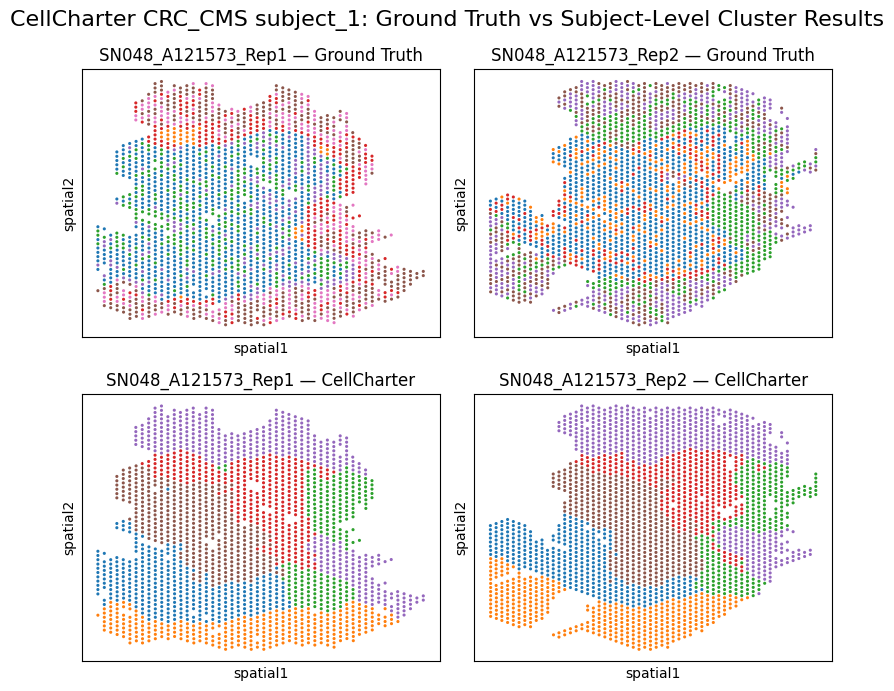

In [14]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

DATA_ROOT  = Path(r"/groups/qiwei/mocha/QuickSRT/CRC_CMS_10x/data")
OUTPUT_DIR = Path(r"/work/dal875013/projects/mocha/results/CellCharter/crc_cms_cellcharter_multi")

SUBJECT_TO_PLOT = "subject_1"
SAMPLES_TO_PLOT = {
    "subject_1": ["SN048_A121573_Rep1", "SN048_A121573_Rep2"],
    "subject_2": ["SN048_A416371_Rep1", "SN048_A416371_Rep2"],
    "subject_3": ["SN123_A551763_Rep1", "SN124_A551763_Rep2"],
    "subject_4": ["SN123_A595688_Rep1", "SN124_A595688_Rep2"],
    "subject_5": ["SN123_A798015_Rep1", "SN124_A798015_Rep2"],
    "subject_6": ["SN123_A938797_Rep1_X", "SN124_A938797_Rep2"],
    "subject_7": ["SN84_A120838_Rep1", "SN84_A120838_Rep2"],
}[SUBJECT_TO_PLOT]

predictions = pd.read_parquet(OUTPUT_DIR / "predictions.parquet")

def find_h5ad_path_for_plot(sample_id):
    candidates = [
        DATA_ROOT / f"SCE_{sample_id}.h5ad",
        DATA_ROOT / f"{sample_id}.h5ad",
        DATA_ROOT / f"adata_{sample_id}.h5ad",
        DATA_ROOT / f"{sample_id}_SCE.h5ad",
    ]
    for p in candidates:
        if p.exists():
            return p
    matches = sorted(DATA_ROOT.glob(f"*{sample_id}*.h5ad"))
    if len(matches) == 1:
        return matches[0]
    raise FileNotFoundError(f"Cannot find unique h5ad file for {sample_id}")

fig, axes = plt.subplots(2, len(SAMPLES_TO_PLOT), figsize=(4 * len(SAMPLES_TO_PLOT), 7))
fig.suptitle(f"CellCharter CRC_CMS {SUBJECT_TO_PLOT}: Ground Truth vs Subject-Level Cluster Results", fontsize=16)

if len(SAMPLES_TO_PLOT) == 1:
    axes = np.asarray(axes).reshape(2, 1)

for j, sample_id in enumerate(SAMPLES_TO_PLOT):
    pred_sample = predictions[predictions["sample"] == sample_id].set_index("spot_id")
    adata = sc.read_h5ad(find_h5ad_path_for_plot(sample_id))

    adata.obs["true_label"] = pred_sample["true_label"].reindex(adata.obs_names).values
    adata.obs["pred_label"] = pred_sample["pred_label"].reindex(adata.obs_names).values

    if "spatial" not in adata.obsm and "S" in adata.obsm:
        adata.obsm["spatial"] = np.asarray(adata.obsm["S"])

    sc.pl.embedding(
        adata, basis="spatial", color="true_label",
        ax=axes[0, j], show=False, title=f"{sample_id} — Ground Truth", s=20,
        legend_loc=None,
    )
    sc.pl.embedding(
        adata, basis="spatial", color="pred_label",
        ax=axes[1, j], show=False, title=f"{sample_id} — CellCharter", s=20,
        legend_loc=None,
    )
    axes[0, j].invert_yaxis()
    axes[1, j].invert_yaxis()

plt.tight_layout()
plt.show()


# Running results summary

In [15]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path(r"/work/dal875013/projects/mocha/results/CellCharter/crc_cms_cellcharter_multi")
perf_path = OUTPUT_DIR / "performance.parquet"

if not perf_path.exists():
    raise FileNotFoundError(f"Cannot find {perf_path}")

performance = pd.read_parquet(perf_path)
performance = performance.sort_values(["training_unit", "sample", "run_seed"]).reset_index(drop=True)

display_cols = [
    "training_unit", "sample", "run_seed",
    "ARI", "NMI", "ACC", "DIS", "HOM", "COM", "V_measure",
    "num_clusters", "num_spots", "num_labeled_spots",
    "num_training_spots", "num_genes_after_hvg",
    "scvi_n_latent", "cellcharter_dim", "n_layers",
    "running_time_sec", "subject_running_time_sec",
    "gpu_model",
]
display_cols = [c for c in display_cols if c in performance.columns]

print("===== All CellCharter subject-level CRC_CMS results =====")
display(performance[display_cols])

print("\n===== Summary =====")
metric_cols = [c for c in ["ARI", "NMI", "ACC", "DIS", "HOM", "COM", "V_measure", "running_time_sec"] if c in performance.columns]
display(performance[metric_cols].describe())

print("\n===== Mean metrics =====")
for col in ["ARI", "NMI", "ACC", "HOM", "COM", "V_measure"]:
    if col in performance.columns:
        print(f"Mean {col}: {performance[col].mean():.4f}")

print("\n===== Subject-level runtime =====")
runtime = performance[["training_unit", "run_seed", "subject_running_time_sec"]].drop_duplicates()
display(runtime)
print(f"Total subject-level runtime: {runtime['subject_running_time_sec'].sum():.2f} sec")

print("\n===== Best / worst ARI =====")
if "ARI" in performance.columns and len(performance) > 0:
    best = performance.loc[performance["ARI"].idxmax()]
    worst = performance.loc[performance["ARI"].idxmin()]
    print(f"Best ARI : {best['sample']} ({best['training_unit']})  ARI={best['ARI']:.4f}")
    print(f"Worst ARI: {worst['sample']} ({worst['training_unit']})  ARI={worst['ARI']:.4f}")


===== All CellCharter subject-level CRC_CMS results =====


,training_unit,sample,run_seed,ARI,NMI,ACC,DIS,HOM,COM,V_measure,...,num_spots,num_labeled_spots,num_training_spots,num_genes_after_hvg,scvi_n_latent,cellcharter_dim,n_layers,running_time_sec,subject_running_time_sec,gpu_model
0,subject_1,SN048_A121573_Rep1,0,0.204097,0.337509,0.355750,NaN,0.340523,0.334548,0.337509,...,2052,2052,4343,2000,10,40,3,60.83,121.66,NVIDIA A30
1,subject_1,SN048_A121573_Rep2,0,0.198669,0.295416,0.379310,NaN,0.301543,0.289533,0.295416,...,2291,2291,4343,2000,10,40,3,60.83,121.66,NVIDIA A30
2,subject_2,SN048_A416371_Rep1,0,0.038413,0.068434,0.326284,NaN,0.077515,0.061258,0.068434,...,2317,2317,4120,2000,10,40,3,56.07,112.14,NVIDIA A30
3,subject_2,SN048_A416371_Rep2,0,0.055157,0.086852,0.344062,NaN,0.101538,0.075877,0.086852,...,1803,1802,4120,2000,10,40,3,56.07,112.14,NVIDIA A30
4,subject_3,SN123_A551763_Rep1,0,0.012363,0.057801,0.359398,NaN,0.066310,0.051228,0.057801,...,665,665,1830,2000,10,40,3,19.05,38.10,NVIDIA A30
5,subject_3,SN124_A551763_Rep2,0,0.006180,0.026234,0.436317,NaN,0.031725,0.022364,0.026234,...,1165,1162,1830,2000,10,40,3,19.05,38.10,NVIDIA A30
6,subject_4,SN123_A595688_Rep1,0,0.318037,0.457875,0.450045,NaN,0.421463,0.501174,0.457875,...,1111,1111,1467,2000,10,40,3,23.75,47.50,NVIDIA A30
7,subject_4,SN124_A595688_Rep2,0,0.353450,0.471552,0.497191,NaN,0.477612,0.465644,0.471552,...,356,356,1467,2000,10,40,3,23.75,47.50,NVIDIA A30
8,subject_5,SN123_A798015_Rep1,0,0.183002,0.346368,0.356743,NaN,0.327097,0.368052,0.346368,...,1635,1609,3209,2000,10,40,3,45.78,91.57,NVIDIA A30
9,subject_5,SN124_A798015_Rep2,0,0.212640,0.389540,0.373478,NaN,0.362425,0.421040,0.389540,...,1574,1478,3209,2000,10,40,3,45.78,91.57,NVIDIA A30



===== Summary =====


,ARI,NMI,ACC,DIS,HOM,COM,V_measure,running_time_sec
count,14.000000,14.000000,14.000000,0.0,14.000000,14.000000,14.000000,14.000000
mean,0.161558,0.273609,0.388395,NaN,0.270287,0.278656,0.273609,39.045714
std,0.105597,0.152380,0.048937,NaN,0.143239,0.162586,0.152380,17.140300
min,0.006180,0.026234,0.326284,NaN,0.031725,0.022364,0.026234,19.050000
25%,0.073565,0.124836,0.355999,NaN,0.136093,0.116365,0.124836,20.592500
50%,0.175400,0.332764,0.376394,NaN,0.326706,0.332144,0.332764,45.780000
75%,0.210504,0.371027,0.424834,NaN,0.356950,0.380803,0.371027,54.127500
max,0.353450,0.471552,0.497191,NaN,0.477612,0.501174,0.471552,60.830000



===== Mean metrics =====
Mean ARI: 0.1616
Mean NMI: 0.2736
Mean ACC: 0.3884
Mean HOM: 0.2703
Mean COM: 0.2787
Mean V_measure: 0.2736

===== Subject-level runtime =====


,training_unit,run_seed,subject_running_time_sec
0,subject_1,0,121.66
2,subject_2,0,112.14
4,subject_3,0,38.10
6,subject_4,0,47.50
8,subject_5,0,91.57
10,subject_6,0,96.59
12,subject_7,0,39.08


Total subject-level runtime: 546.64 sec

===== Best / worst ARI =====
Best ARI : SN124_A595688_Rep2 (subject_4)  ARI=0.3535
Worst ARI: SN124_A551763_Rep2 (subject_3)  ARI=0.0062


# Compare single-sample vs subject-level results

In [16]:
import pandas as pd
from pathlib import Path

SINGLE_DIR = Path(r"/work/dal875013/projects/mocha/results/CellCharter/crc_cms_cellcharter")
MULTI_DIR  = Path(r"/work/dal875013/projects/mocha/results/CellCharter/crc_cms_cellcharter_multi")

single_path = SINGLE_DIR / "performance.parquet"
multi_path = MULTI_DIR / "performance.parquet"

if not single_path.exists():
    print(f"[SKIP] Cannot find single-sample results: {single_path}")
elif not multi_path.exists():
    print(f"[SKIP] Cannot find subject-level results: {multi_path}")
else:
    single = pd.read_parquet(single_path).copy()
    multi = pd.read_parquet(multi_path).copy()


    single["setting"] = "single_sample"
    multi["setting"] = "subject_level"

    cols = ["setting", "training_unit", "sample", "run_seed", "ARI", "NMI", "ACC", "HOM", "COM", "V_measure", "running_time_sec"]
    cols = [c for c in cols if c in single.columns or c in multi.columns]

    combined = pd.concat([single, multi], ignore_index=True, sort=False)
    display(combined[cols].sort_values(["sample", "setting"]).reset_index(drop=True))

    print("\n===== Mean by setting =====")
    metric_cols = [c for c in ["ARI", "NMI", "ACC", "HOM", "COM", "V_measure", "running_time_sec"] if c in combined.columns]
    display(combined.groupby("setting")[metric_cols].mean())

    print("\n===== Per-sample subject-level minus single-sample =====")
    s = single.set_index(["sample", "run_seed"])
    m = multi.set_index(["sample", "run_seed"])
    delta = pd.DataFrame(index=m.index)
    for col in ["ARI", "NMI", "ACC", "HOM", "COM", "V_measure"]:
        if col in s.columns and col in m.columns:
            delta[f"delta_{col}"] = m[col] - s[col]
    display(delta.reset_index().sort_values(["sample", "run_seed"]))


,setting,training_unit,sample,run_seed,ARI,NMI,ACC,HOM,COM,V_measure,running_time_sec
0,single_sample,SN048_A121573_Rep1,SN048_A121573_Rep1,0,0.214812,0.348256,0.403996,0.349499,0.347020,0.348256,37.10
1,subject_level,subject_1,SN048_A121573_Rep1,0,0.204097,0.337509,0.355750,0.340523,0.334548,0.337509,60.83
2,single_sample,SN048_A121573_Rep2,SN048_A121573_Rep2,0,0.240406,0.340714,0.446093,0.347546,0.334146,0.340714,31.81
3,subject_level,subject_1,SN048_A121573_Rep2,0,0.198669,0.295416,0.379310,0.301543,0.289533,0.295416,60.83
4,single_sample,SN048_A416371_Rep1,SN048_A416371_Rep1,0,0.068638,0.128622,0.336211,0.150866,0.112094,0.128622,31.86
5,subject_level,subject_2,SN048_A416371_Rep1,0,0.038413,0.068434,0.326284,0.077515,0.061258,0.068434,56.07
6,single_sample,SN048_A416371_Rep2,SN048_A416371_Rep2,0,0.067175,0.112668,0.324084,0.132627,0.097930,0.112668,35.21
7,subject_level,subject_2,SN048_A416371_Rep2,0,0.055157,0.086852,0.344062,0.101538,0.075877,0.086852,56.07
8,single_sample,SN123_A551763_Rep1,SN123_A551763_Rep1,0,0.026312,0.062492,0.281203,0.085700,0.049175,0.062492,13.06
9,subject_level,subject_3,SN123_A551763_Rep1,0,0.012363,0.057801,0.359398,0.066310,0.051228,0.057801,19.05



===== Mean by setting =====


,ARI,NMI,ACC,HOM,COM,V_measure,running_time_sec
setting,,,,,,,
single_sample,0.174170,0.293393,0.384011,0.298861,0.291610,0.293393,32.135000
subject_level,0.161558,0.273609,0.388395,0.270287,0.278656,0.273609,39.045714



===== Per-sample subject-level minus single-sample =====


,sample,run_seed,delta_ARI,delta_NMI,delta_ACC,delta_HOM,delta_COM,delta_V_measure
0,SN048_A121573_Rep1,0,-0.010715,-0.010746,-0.048246,-0.008976,-0.012472,-0.010746
1,SN048_A121573_Rep2,0,-0.041736,-0.045298,-0.066783,-0.046002,-0.044613,-0.045298
2,SN048_A416371_Rep1,0,-0.030225,-0.060187,-0.009927,-0.073351,-0.050836,-0.060187
3,SN048_A416371_Rep2,0,-0.012019,-0.025816,0.019978,-0.031090,-0.022053,-0.025816
4,SN123_A551763_Rep1,0,-0.013950,-0.004691,0.078195,-0.019390,0.002053,-0.004691
6,SN123_A595688_Rep1,0,0.031148,0.000802,0.018902,-0.009974,0.015225,0.000802
8,SN123_A798015_Rep1,0,-0.027969,-0.013362,-0.025482,-0.011587,-0.015514,-0.013362
10,SN123_A938797_Rep1_X,0,0.026442,0.031632,0.039095,0.031094,0.032188,0.031632
5,SN124_A551763_Rep2,0,-0.020211,-0.020946,0.184165,-0.041974,-0.012332,-0.020946
7,SN124_A595688_Rep2,0,-0.016524,-0.058617,-0.047753,-0.077221,-0.041960,-0.058617
